In [21]:
from abc import ABC, abstractmethod

# normalize

class Normalizer(ABC):
    @abstractmethod
    def fit(self, X): ...

    @abstractmethod
    def transform(self, X): ...

    @abstractmethod
    def inverse(self, X): ...

    def fit_transform(self, X):
        return self.fit(X).transform(X)


class MinMaxNormalizer(Normalizer):
    def fit(self, X):
        self.min = X.min(axis=0)
        self.max = X.max(axis=0)
        return self

    def transform(self, x):
        return (x - self.min) / (self.max - self.min)

    def inverse(self, x):
        return x * (self.max - self.min) + self.min



class ZScoreNormalizer(Normalizer):
    def fit(self, x):
        self.mean = x.mean(axis=0)
        self.std = x.std(axis=0)
        return self

    def transform(self, x):
        return (x - self.mean) / self.std

    def inverse(self, x):
        return x * self.std + self.mean

In [22]:
import numpy as np

class Metric(ABC):
    @abstractmethod
    def name(self) -> str: ...
    @abstractmethod
    def compute(self, y_true, y_pred) -> float: ...

class MSEMetric(Metric):
    def name(self): return "MSE"
    def compute(self, y_true, y_pred):
        return ((y_pred - y_true) ** 2).mean()

class MAEMetric(Metric):
    def name(self): return "MAE"
    def compute(self, y_true, y_pred):
        return np.abs(y_pred - y_true).mean()

class RMSEMetric(Metric):
    def name(self): return "RMSE"
    def compute(self, y_true, y_pred):
        return ((y_pred - y_true) ** 2).mean() ** 0.5

class R2(Metric):
    def name(self): return "R2"
    def compute(self, y_true, y_pred):
        ss_res = ((y_true - y_pred) ** 2).sum()
        ss_tot = ((y_true - y_true.mean()) ** 2).sum()
        return 1 - ss_res / ss_tot

class MAPE(Metric):
    def name(self): return "MAPE"
    def compute(self, y_true, y_pred):
        mask = y_true != 0
        return np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]).mean() * 100

class MaxError(Metric):
    def name(self): return "MaxErr"
    def compute(self, y_true, y_pred):
        return np.abs(y_true - y_pred).max()


class LossFunction(ABC):
    @abstractmethod
    def name(self) -> str: ...
    @abstractmethod
    def loss(self, y, y_pred) -> float: ...
    @abstractmethod
    def grad(self, X, y, y_pred): ...

class MSELoss(LossFunction):
    def name(self): return "MSE"
    def loss(self, y, y_pred):
        return ((y_pred - y) ** 2).mean()
    def grad(self, X, y, y_pred):
        n = len(y)
        err = y_pred - y
        return (2/n) * X.T @ err, (2/n) * err.sum()

class MAELoss(LossFunction):
    def name(self): return "MAE"
    def loss(self, y, y_pred):
        return np.abs(y_pred - y).mean()
    def grad(self, X, y, y_pred):
        n = len(y)
        s = np.sign(y_pred - y)
        return (1/n) * X.T @ s, (1/n) * s.sum()

class RMSELoss(LossFunction):
    def __init__(self):
        self._mse = MSELoss()
    def name(self): return "RMSE"
    def loss(self, y, y_pred):
        return self._mse.loss(y, y_pred) ** 0.5
    def grad(self, X, y, y_pred):
        mse_val = self._mse.loss(y, y_pred)
        w_grad, b_grad = self._mse.grad(X, y, y_pred)
        scale = 1 / (2 * mse_val ** 0.5 + 1e-12)
        return scale * w_grad, scale * b_grad

In [23]:
class R2(Metric):
    def name(self): return "R2"

    def compute(self, y_true, y_pred):
        ss_res = ((y_true - y_pred) ** 2).sum()
        ss_tot = ((y_true - y_true.mean()) ** 2).sum()
        return 1 - ss_res / ss_tot


class MAPE(Metric):
    def name(self): return "MAPE"

    def compute(self, y_true, y_pred):
        mask = y_true != 0
        return (np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])).mean() * 100


class MaxError(Metric):
    def name(self): return "MaxErr"

    def compute(self, y_true, y_pred):
        return np.abs(y_true - y_pred).max()

In [24]:
class Evaluator:
    def __init__(self, metrics: list[Metric]):
        self.metrics = metrics
    def evaluate(self, y_true, y_pred) -> dict:
        return {m.name(): m.compute(y_true, y_pred) for m in self.metrics}
    def header(self) -> str:
        return "  ".join(f"{m.name():>10}" for m in self.metrics)
    def row(self, scores: dict) -> str:
        return "  ".join(f"{scores[m.name()]:>10.4f}" for m in self.metrics)

In [25]:
def remove_outliers_iqr(df, cols, k=1.5):
    mask = np.ones(len(df), dtype=bool)
    for col in cols:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        mask &= (df[col].values >= q1 - k * iqr) & (df[col].values <= q3 + k * iqr)
    return df[mask].reset_index(drop=True)

def linear(x, weights, bias):
    return x @ weights + bias

rng = np.random.default_rng(seed=42)

def train_model(x, y, loss_fn, lr, snapshot_every=500, tol=1e-6, patience=20, max_epochs=50_000):
    n, d = x.shape
    weights    = rng.uniform(size=d)
    bias       = rng.uniform()
    prev_loss  = float("inf")
    no_improve = 0
    history    = []
    status     = "max_epochs"
    l          = float("inf")

    for epoch in range(max_epochs):
        y_pred = linear(x, weights, bias)
        l      = loss_fn.loss(y, y_pred)

        if np.isnan(l) or np.isinf(l):
            print(f"  diverged at epoch {epoch}")
            status = "diverged"
            break

        w_grad, b_grad = loss_fn.grad(x, y, y_pred)
        weights -= lr * w_grad
        bias    -= lr * b_grad
        history.append(l)

        if epoch % snapshot_every == 0:
            print(f"  epoch {epoch:>6}  loss {l:.6f}")

        # skip convergence check on first epoch — prev_loss is sentinel inf
        if prev_loss != float("inf"):
            rel_change = abs(prev_loss - l) / (abs(prev_loss) + 1e-12)
            if rel_change < tol:
                no_improve += 1
                if no_improve >= patience:
                    print(f"  converged at epoch {epoch}  loss {l:.6f}")
                    status = "converged"
                    break
            else:
                no_improve = 0

        prev_loss = l

    if status == "max_epochs":
        print(f"  WARNING: did not converge after {max_epochs} epochs  loss {l:.6f}")

    return weights, bias, history, status

def lr_sweep(x_tr, y_tr, loss_fn, candidates=(1e-1, 1e-2, 1e-3, 1e-4)):
    print(f"\n  lr sweep for {loss_fn.name()}")
    print(f"  {'lr':>10}  {'final loss':>12}  {'status':>10}")
    print("  " + "-" * 36)

    best_lr, best_loss, best_status = None, float("inf"), "max_epochs"

    for lr in candidates:
        _, _, history, status = train_model(
            x_tr, y_tr, loss_fn, lr,
            snapshot_every=999_999,   # suppress per-epoch output
            max_epochs=50_000,
        )
        final = history[-1] if history else float("inf")
        print(f"  {lr:>10.0e}  {final:>12.6f}  {status:>10}")

        # prefer converging runs; among those, pick lowest final loss
        if status == "converged" and (best_status != "converged" or final < best_loss):
            best_lr, best_loss, best_status = lr, final, status

    print(f"  → selected lr = {best_lr}  (status={best_status})")
    return best_lr, best_status

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split

column_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
    'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV',
]

data = pd.read_csv("../shared_data/housing.csv", names=column_names, delimiter=r"\s+")
train, test = train_test_split(data, test_size=0.2, random_state=42)

print(f"Train: {len(train)}, Test: {len(test)}")

FEATURES = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
            'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
TARGET = 'MEDV'

CONTINUOUS_FEATURES = [f for f in FEATURES if f != 'CHAS']
# train = remove_outliers_iqr(train, CONTINUOUS_FEATURES + [TARGET], k=3.0)
print(f"Train after outlier removal: {len(train)}")

raw_X_train = train[FEATURES].values
raw_y_train = train[TARGET].values
raw_X_test = test[FEATURES].values
raw_y_test = test[TARGET].values

variances = raw_X_train.std(axis=0)
valid_mask = variances > 0

if not valid_mask.all():
    dropped = [f for f, v in zip(FEATURES, valid_mask) if not v]
    print(f"Dropping zero-variance features: {dropped}")
    FEATURES = [f for f, v in zip(FEATURES, valid_mask) if v]
    raw_X_train = raw_X_train[:, valid_mask]
    raw_X_test = raw_X_test[:, valid_mask]


Train: 404, Test: 102
Train after outlier removal: 404


In [27]:

norm_configs = [
    ("MinMax",  MinMaxNormalizer(), MinMaxNormalizer()),
    ("Z-score", ZScoreNormalizer(), ZScoreNormalizer()),
]
loss_fns: list[LossFunction] = [MSELoss(), MAELoss(), RMSELoss()]
evaluator = Evaluator([MSEMetric(), MAEMetric(), RMSEMetric(), R2(), MAPE(), MaxError()])

LR_CANDIDATES = (1e-1, 1e-2, 1e-3, 1e-4, 1e-5)

results = []


for norm_label, x_norm, y_norm in norm_configs:
    X_tr = x_norm.fit_transform(raw_X_train)
    y_tr = y_norm.fit_transform(raw_y_train)
    X_te = x_norm.transform(raw_X_test)

    for loss_fn in loss_fns:
        print(f"\n=== {norm_label} + {loss_fn.name()} ===")

        best_lr, best_status = lr_sweep(X_tr, y_tr, loss_fn, LR_CANDIDATES)

        if best_status != "converged":
            print(f"  SKIPPING {norm_label}+{loss_fn.name()}: no lr converged (status={best_status})")
            continue

        print(f"\n  training with lr={best_lr:.0e}")
        weights, bias, history, _ = train_model(X_tr, y_tr, loss_fn, best_lr)

        y_pred = y_norm.inverse(linear(X_te, weights, bias))
        scores = evaluator.evaluate(raw_y_test, y_pred)

        results.append({
            "norm": norm_label, "loss": loss_fn.name(),
            "lr": best_lr, "converged": converged,
            "scores": scores, "weights": weights,
            "bias": bias, "history": history,
        })


print(f"\n{'Norm':<10} {'Loss':<6} {evaluator.header()}")
print("-" * (18 + len(evaluator.header())))
for r in results:
    print(f"{r['norm']:<10} {r['loss']:<6} {evaluator.row(r['scores'])}")

best = max(results, key=lambda r: r["scores"]["R2"])
print(f"\nBest model: {best['norm']} + {best['loss']} (R2 = {best['scores']['R2']:.4f})")
print("\nFeature weights (normalized scale):")
for feat, w in sorted(zip(FEATURES, best["weights"]), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feat:<10} {w:>+.4f}")


=== MinMax + MSE ===

  lr sweep for MSE
          lr    final loss      status
  ------------------------------------
  epoch      0  loss 13.286921
  converged at epoch 4178  loss 0.010693
       1e-01      0.010693   converged
  epoch      0  loss 8.321904
  converged at epoch 27919  loss 0.010751
       1e-02      0.010751   converged
  epoch      0  loss 7.413168
       1e-03      0.011295  max_epochs
  epoch      0  loss 9.341973
       1e-04      0.051514  max_epochs
  epoch      0  loss 5.795532
       1e-05      0.114200  max_epochs
  → selected lr = 0.1  (status=converged)

  training with lr=1e-01
  epoch      0  loss 5.673927
  epoch    500  loss 0.013137
  epoch   1000  loss 0.011648
  epoch   1500  loss 0.011096
  epoch   2000  loss 0.010863
  epoch   2500  loss 0.010763
  epoch   3000  loss 0.010720
  epoch   3500  loss 0.010701
  converged at epoch 3998  loss 0.010693

=== MinMax + MAE ===

  lr sweep for MAE
          lr    final loss      status
  -------------------

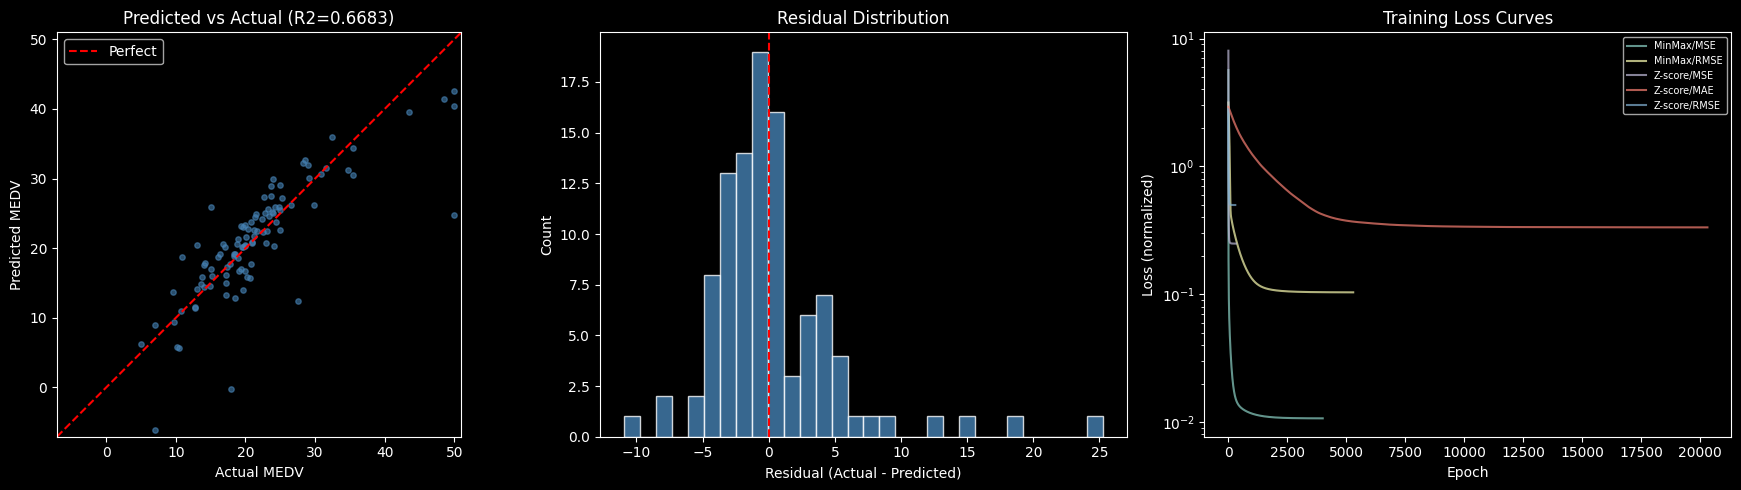

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

norm_cfg = [c for c in norm_configs if c[0] == best["norm"]][0]
y_pred_best = norm_cfg[2].inverse(
    linear(norm_cfg[1].transform(raw_X_test), best["weights"], best["bias"])
)

ax = axes[0]
ax.scatter(raw_y_test, y_pred_best, s=15, alpha=0.6, color="steelblue")
lims = [
    min(raw_y_test.min(), y_pred_best.min()) - 1,
    max(raw_y_test.max(), y_pred_best.max()) + 1,
]
ax.plot(lims, lims, color="red", linewidth=1.5, linestyle="--", label="Perfect")
ax.set_xlabel("Actual MEDV")
ax.set_ylabel("Predicted MEDV")
ax.set_title(f"Predicted vs Actual (R2={best['scores']['R2']:.4f})")
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")

residuals = raw_y_test - y_pred_best
ax = axes[1]
ax.hist(residuals, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Residual (Actual - Predicted)")
ax.set_ylabel("Count")
ax.set_title("Residual Distribution")

ax = axes[2]
for r in results:
    ax.plot(r["history"], label=f"{r['norm']}/{r['loss']}", alpha=0.7)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (normalized)")
ax.set_title("Training Loss Curves")
ax.legend(fontsize=7)
ax.set_yscale("log")

plt.tight_layout()
plt.savefig("multivariable_analysis.png", dpi=150, bbox_inches="tight")
plt.show()